In [ ]:
import zipfile

zip_path = "/content/Orange Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:

import os

print(os.listdir("/content"))

['.config', 'train', 'test', 'Orange Dataset.zip', 'sample_data']


In [ ]:
root="/content"

In [ ]:
import os

print(os.listdir(root+"/train"))
print(os.listdir(root+"/test"))

['blackspot', 'grenning', 'canker', 'fresh']
['blackspot', 'grenning', 'canker', 'fresh']


In [ ]:
#DATA EXPLORATION

In [ ]:
import os

for split in ["train","test"]:

    print("\n"+split.upper())

    split_path=os.path.join(root,split)

    for cls in os.listdir(split_path):

        folder=os.path.join(split_path,cls)

        count=len(os.listdir(folder))

        print(cls,":",count)


TRAIN
blackspot : 184
grenning : 347
canker : 179
fresh : 281

TEST
blackspot : 22
grenning : 22
canker : 22
fresh : 33


In [ ]:
from PIL import Image
import os

bad=[]

for split in ["train","test"]:

    for cls in os.listdir(root+"/"+split):

        folder=os.path.join(root,split,cls)

        for img in os.listdir(folder):

            try:
                Image.open(
                    os.path.join(folder,img)
                ).verify()

            except:
                bad.append(
                    os.path.join(folder,img)
                )

print("Corrupted images:",len(bad))

Corrupted images: 0


In [ ]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.9 MB/s eta 0:00:00


In [ ]:
import imagehash
from PIL import Image

seen={}
duplicates=[]

for split in ["train","test"]:

    for cls in os.listdir(root+"/"+split):

        folder=os.path.join(root,split,cls)

        for img in os.listdir(folder):

            path=os.path.join(folder,img)

            try:

                h=str(
                    imagehash.average_hash(
                        Image.open(path)
                    )
                )

                if h in seen:
                    duplicates.append(
                        (path,seen[h])
                    )

                else:
                    seen[h]=path

            except:
                pass

print("Duplicate images:",len(duplicates))

Duplicate images: 125


In [ ]:
print(duplicates[:10])

[('/content/train/grenning/g (264).jpg', '/content/train/grenning/g (108).jpg'), ('/content/train/grenning/g (102).jpg', '/content/train/grenning/g (80).jpg'), ('/content/train/grenning/g (337).jpg', '/content/train/grenning/g (125).jpg'), ('/content/train/grenning/g (79).jpg', '/content/train/grenning/g (250).jpg'), ('/content/train/grenning/g (236).jpg', '/content/train/grenning/g (292).jpg'), ('/content/train/grenning/g (60).jpg', '/content/train/grenning/g (108).jpg'), ('/content/train/grenning/g (124).jpg', '/content/train/grenning/g (125).jpg'), ('/content/train/grenning/g (61).jpg', '/content/train/grenning/g (284).jpg'), ('/content/train/grenning/g (67).jpg', '/content/train/grenning/g (125).jpg'), ('/content/train/grenning/g (206).jpg', '/content/train/grenning/g (125).jpg')]


In [ ]:
train_train=0
test_test=0
train_test=0

for a,b in duplicates:

    if "/train/" in a and "/train/" in b:
        train_train+=1

    elif "/test/" in a and "/test/" in b:
        test_test+=1

    else:
        train_test+=1

print("Train duplicates:",train_train)
print("Test duplicates:",test_test)
print("Train-Test leakage:",train_test)

Train duplicates: 115
Test duplicates: 0
Train-Test leakage: 10


In [ ]:
to_delete=[]

seen={}

for split in ["train","test"]:

    for cls in os.listdir(root+"/"+split):

        folder=os.path.join(root,split,cls)

        for img in os.listdir(folder):

            path=os.path.join(folder,img)

            try:

                h=str(
                    imagehash.average_hash(
                        Image.open(path)
                    )
                )

                if h in seen:
                    to_delete.append(path)

                else:
                    seen[h]=path

            except:
                pass

print("Will remove:",len(to_delete))

Will remove: 125


In [ ]:
import os

removed=0

for f in to_delete:
    try:
        os.remove(f)
        removed+=1
    except:
        pass

print("Removed:",removed)

Removed: 125


In [ ]:
for split in ["train","test"]:

    print("\n"+split.upper())

    for cls in os.listdir(root+"/"+split):

        folder=os.path.join(root,split,cls)

        print(
            cls,
            len(os.listdir(folder))
        )


TRAIN
blackspot 184
grenning 239
canker 178
fresh 275

TEST
blackspot 21
grenning 13
canker 22
fresh 33


In [ ]:
print("Corrupted:", len(bad))

Corrupted: 0


In [ ]:
from PIL import Image
import numpy as np
import os

outliers=[]

for split in ["train","test"]:

    for cls in os.listdir(root+"/"+split):

        folder=os.path.join(root,split,cls)

        for img in os.listdir(folder):

            try:

                path=os.path.join(folder,img)

                image=np.array(
                    Image.open(path)
                )

                brightness=image.mean()

                # very dark or very bright
                if brightness < 30 or brightness > 230:
                    outliers.append(path)

            except:
                pass

print("Potential outliers:", len(outliers))

Potential outliers: 41


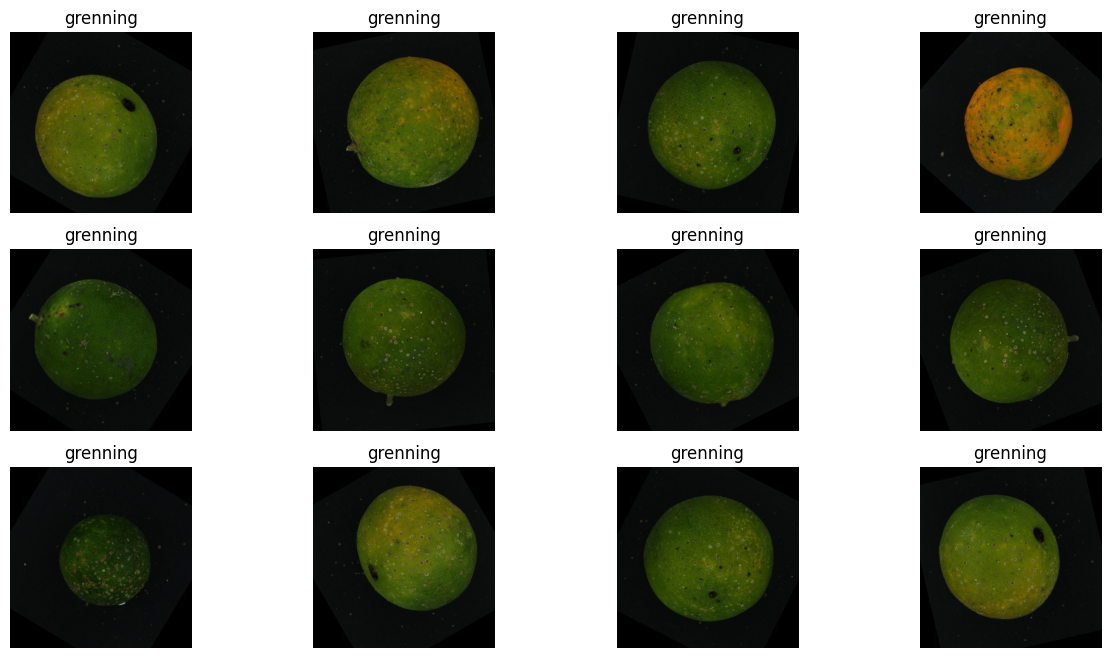

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15,8))

for i,path in enumerate(outliers[:12]):

    img=Image.open(path)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(path.split("/")[-2])

    plt.axis("off")

plt.show()

In [ ]:
#APPROACH 1- HSV+LBP+SVM

In [ ]:
!pip install opencv-python scikit-image scikit-learn

In [ ]:
import os
import cv2
import numpy as np

from PIL import Image
from skimage.feature import local_binary_pattern

root="/content"

IMG_SIZE=128

LBP_POINTS=24
LBP_RADIUS=3

In [ ]:
#FEATURE EXTRACTION

In [ ]:
def extract_features(image_path):

    img=cv2.imread(image_path)

    img=cv2.resize(
        img,
        (IMG_SIZE,IMG_SIZE)
    )

    # ---------- HSV ----------
    hsv=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    hsv_hist=cv2.calcHist(
        [hsv],
        [0,1],
        None,
        [8,8],
        [0,180,0,256]
    )

    hsv_hist=cv2.normalize(
        hsv_hist,
        hsv_hist
    ).flatten()

    # ---------- LBP ----------
    gray=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    lbp=local_binary_pattern(
        gray,
        LBP_POINTS,
        LBP_RADIUS,
        method="uniform"
    )

    lbp_hist,_=np.histogram(
        lbp.ravel(),
        bins=np.arange(
            0,
            LBP_POINTS+3
        ),
        range=(
            0,
            LBP_POINTS+2
        )
    )

    lbp_hist=lbp_hist.astype("float")

    lbp_hist/=(
        lbp_hist.sum()+1e-6
    )

    feature=np.concatenate(
        [
            hsv_hist,
            lbp_hist
        ]
    )

    return feature

In [ ]:
X_train=[]
y_train=[]

for cls in os.listdir(root+"/train"):

    folder=os.path.join(
        root,
        "train",
        cls
    )

    print("Loading",cls)

    for img in os.listdir(folder):

        try:

            path=os.path.join(
                folder,
                img
            )

            feature=extract_features(
                path
            )

            X_train.append(
                feature
            )

            y_train.append(
                cls
            )

        except:
            pass

X_train=np.array(X_train)
y_train=np.array(y_train)

print(X_train.shape)

Loading blackspot
Loading grenning
Loading canker
Loading fresh
(876, 90)


In [ ]:
X_test=[]
y_test=[]

for cls in os.listdir(root+"/test"):

    folder=os.path.join(
        root,
        "test",
        cls
    )

    print("Loading",cls)

    for img in os.listdir(folder):

        try:

            path=os.path.join(
                folder,
                img
            )

            feature=extract_features(
                path
            )

            X_test.append(
                feature
            )

            y_test.append(
                cls
            )

        except:
            pass

X_test=np.array(X_test)
y_test=np.array(y_test)

print(X_test.shape)

Loading blackspot
Loading grenning
Loading canker
Loading fresh
(89, 90)


In [ ]:
from sklearn.svm import SVC

model=SVC(

    kernel="rbf",

    C=10,

    gamma="scale",

    class_weight="balanced"

)

model.fit(
    X_train,
    y_train
)

print("Training complete")

Training complete


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pred=model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.9550561797752809
              precision    recall  f1-score   support

   blackspot       0.84      1.00      0.91        21
      canker       1.00      0.82      0.90        22
       fresh       1.00      1.00      1.00        33
    grenning       1.00      1.00      1.00        13

    accuracy                           0.96        89
   macro avg       0.96      0.95      0.95        89
weighted avg       0.96      0.96      0.95        89



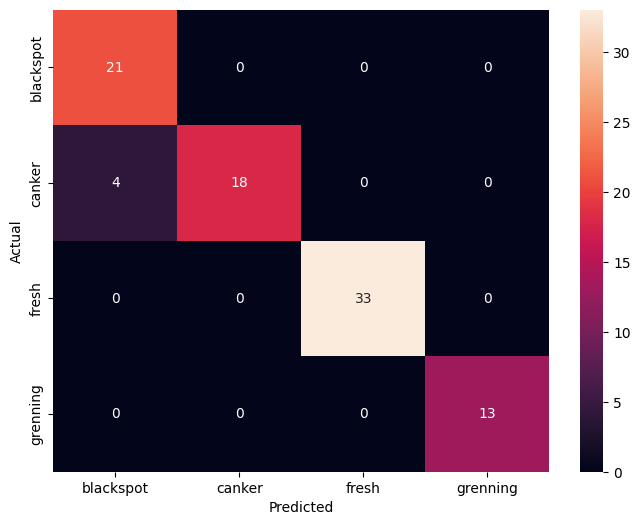

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm=confusion_matrix(
    y_test,
    pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [ ]:
#APPROACH 2 - Deep Learning (MobileNetV2 + Transfer Learning).

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.applications import (
    MobileNetV2
)

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

from tensorflow.keras.models import Model

In [ ]:
IMG_SIZE=(224,224)

train_gen=ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input,

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True
)

test_gen=ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input
)

train_data=train_gen.flow_from_directory(

    "/content/train",

    target_size=IMG_SIZE,

    batch_size=32,

    class_mode="categorical"
)

test_data=test_gen.flow_from_directory(

    "/content/test",

    target_size=IMG_SIZE,

    batch_size=32,

    shuffle=False,

    class_mode="categorical"
)

Found 876 images belonging to 4 classes.
Found 89 images belonging to 4 classes.


In [ ]:
base=MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)
)

base.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x=base.output

x=GlobalAveragePooling2D()(x)

x=Dropout(0.3)(x)

out=Dense(

    4,

    activation="softmax"

)(x)

model=Model(

    inputs=base.input,

    outputs=out
)

In [ ]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history=model.fit(

    train_data,

    epochs=10,

    validation_data=test_data
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7295 - loss: 0.7642 - val_accuracy: 0.8989 - val_loss: 0.2550
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9555 - loss: 0.1874 - val_accuracy: 0.9213 - val_loss: 0.1891
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9726 - loss: 0.1168 - val_accuracy: 0.9101 - val_loss: 0.1849
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9669 - loss: 0.1097 - val_accuracy: 0.8989 - val_loss: 0.1841
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9760 - loss: 0.0891 - val_accuracy: 0.9326 - val_loss: 0.1722
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9680 - loss: 0.0874 - val_accuracy: 0.9213 - val_loss: 0.1767
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9806 - loss: 0.0717 - val_accuracy: 0.9326 - val_loss: 0.1747
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9806 - loss: 0.0733 - val_accuracy: 0.9326 - val_loss:

In [ ]:
loss,acc=model.evaluate(
    test_data
)

print(
    "Test Accuracy:",
    acc
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9438 - loss: 0.1644
Test Accuracy: 0.9438202381134033


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

pred=model.predict(
    test_data
)

pred=np.argmax(
    pred,
    axis=1
)

true=test_data.classes

print(

classification_report(

true,

pred,

target_names=
list(
test_data.class_indices.keys()
)

)

)

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
              precision    recall  f1-score   support

   blackspot       0.86      0.90      0.88        21
      canker       0.90      0.86      0.88        22
       fresh       1.00      1.00      1.00        33
    grenning       1.00      1.00      1.00        13

    accuracy                           0.94        89
   macro avg       0.94      0.94      0.94        89
weighted avg       0.94      0.94      0.94        89



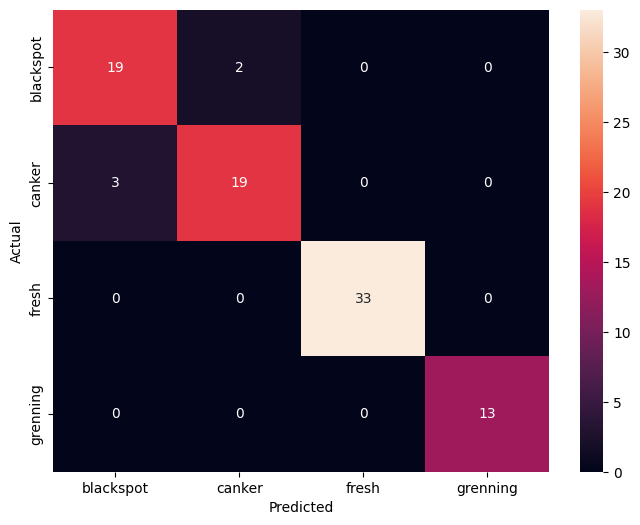

In [ ]:
import seaborn as sns

cm=confusion_matrix(
    true,
    pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(

cm,

annot=True,

fmt="d",

xticklabels=
list(
test_data.class_indices.keys()
),

yticklabels=
list(
test_data.class_indices.keys()
)

)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

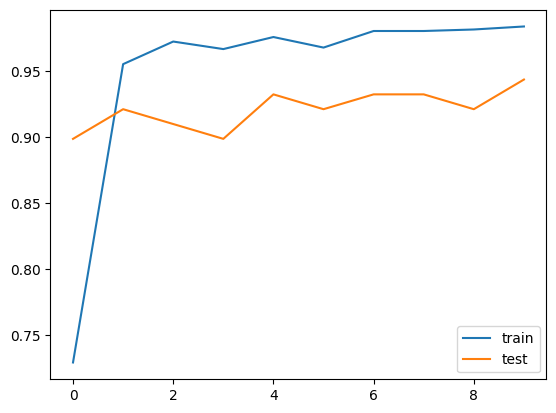

In [ ]:
plt.plot(
history.history["accuracy"]
)

plt.plot(
history.history["val_accuracy"]
)

plt.legend([
"train",
"test"
])

plt.show()